# Cohort Analysis Tool

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-accelerator/cohort-analysis/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-accelerator/cohort-analysis/demo.ipynb)

Retention analysis that used to take an analyst 2 days, done in one notebook run.

**What this notebook covers:**
1. Generate a mock event log (signups + repeat activity)
2. Tag each event with its signup cohort and period number
3. Build a cohort x period retention matrix
4. Visualize retention decay as a heatmap
5. Try it with your own data

## Step 1: What we're building

A cohort retention analysis groups users by the month they signed up, then tracks what
percentage of each cohort is still active 1, 2, 3... months later. This reveals whether
retention is improving over time and how fast users churn after signup.

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd


def assign_cohort(df: pd.DataFrame, user_col: str, date_col: str) -> pd.DataFrame:
    """Tag each event with the user's signup cohort month and period index."""
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df["cohort_month"] = df.groupby(user_col)[date_col].transform("min").dt.to_period("M")
    df["event_month"] = df[date_col].dt.to_period("M")
    df["period_number"] = (df["event_month"] - df["cohort_month"]).apply(lambda p: p.n)
    return df


def build_retention_matrix(
    df: pd.DataFrame, user_col: str = "user_id", date_col: str = "event_date"
) -> pd.DataFrame:
    """Return a cohort x period retention-rate matrix (percent of cohort active)."""
    tagged = assign_cohort(df, user_col, date_col)

    cohort_sizes = (
        tagged[tagged["period_number"] == 0].groupby("cohort_month")[user_col].nunique()
    )

    active = (
        tagged.groupby(["cohort_month", "period_number"])[user_col]
        .nunique()
        .reset_index(name="active_users")
    )

    pivot = active.pivot(index="cohort_month", columns="period_number", values="active_users")
    retention = pivot.divide(cohort_sizes, axis=0) * 100
    retention.index = retention.index.astype(str)
    return retention.round(1)


def generate_sample_events(n_users: int = 500, n_months: int = 6, seed: int = 42) -> pd.DataFrame:
    """Mock signup + repeat-activity event log for demoing the tool without real data."""
    rng = np.random.default_rng(seed)
    start = pd.Timestamp("2025-01-01")

    signup_months = rng.integers(0, n_months, size=n_users)
    rows = []
    for uid in range(n_users):
        signup_month = signup_months[uid]
        signup_date = start + pd.DateOffset(months=int(signup_month), days=int(rng.integers(0, 28)))
        rows.append({"user_id": uid, "event_date": signup_date})

        decay = rng.uniform(0.55, 0.75)
        for period in range(1, n_months - signup_month):
            if rng.random() < decay**period:
                event_date = signup_date + pd.DateOffset(months=period, days=int(rng.integers(0, 28)))
                rows.append({"user_id": uid, "event_date": event_date})

    return pd.DataFrame(rows)

print("Functions defined.")

Functions defined.


## Step 2: Generate a mock event log

500 users signing up over 6 months, each with a randomized retention decay rate.

In [2]:
events = generate_sample_events(n_users=500, n_months=6)
print(f"{len(events)} events across {events['user_id'].nunique()} users")
events.head()

1036 events across 500 users


,user_id,event_date
0,0,2025-01-04
1,0,2025-02-22
2,0,2025-03-11
3,0,2025-06-10
4,1,2025-05-25


## Step 3: Build the retention matrix

Each row is a signup cohort (month), each column is months-since-signup, and each
cell is the percent of that cohort still active.

In [3]:
retention = build_retention_matrix(events)
retention

period_number,0,1,2,3,4,5,6
cohort_month,,,,,,,
2025-01,100.0,36.0,51.7,29.2,18.0,16.9,2.2
2025-02,100.0,40.0,45.0,30.0,17.5,17.5,NaN
2025-03,100.0,35.6,50.6,31.0,12.6,NaN,NaN
2025-04,100.0,31.2,51.9,19.5,NaN,NaN,NaN
2025-05,100.0,38.3,31.9,NaN,NaN,NaN,NaN
2025-06,100.0,NaN,NaN,NaN,NaN,NaN,NaN


## Step 4: Visualize retention decay

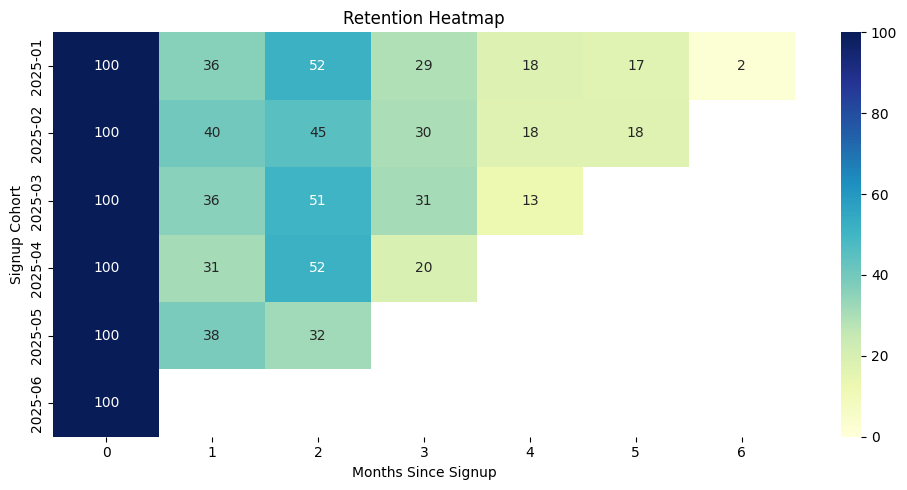

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(retention, annot=True, fmt=".0f", cmap="YlGnBu", vmin=0, vmax=100, ax=ax)
ax.set_xlabel("Months Since Signup")
ax.set_ylabel("Signup Cohort")
ax.set_title("Retention Heatmap")
plt.tight_layout()
plt.savefig("retention_heatmap.png", dpi=150)
plt.show()

## Summary

Month-1 retention sits in the 30-40% range across cohorts, with no clear improvement
trend over the 6 months sampled here. In a real dataset, a declining diagonal would
flag retention regressing for newer cohorts; a rising one would confirm a fix landed.

In [5]:
month1 = retention[1].dropna()
print(f"Average Month-1 retention: {month1.mean():.1f}%")
print(f"Best cohort: {month1.idxmax()} at {month1.max():.1f}%")
print(f"Worst cohort: {month1.idxmin()} at {month1.min():.1f}%")

Average Month-1 retention: 36.2%
Best cohort: 2025-02 at 40.0%
Worst cohort: 2025-04 at 31.2%


## Try Your Own

Swap in a real event log with `user_id` and `event_date` columns:

```python
# my_events = pd.read_csv("my_events.csv")
# my_retention = build_retention_matrix(my_events, user_col="user_id", date_col="event_date")
# my_retention
```

---
Part of the [Phoebe the Builder](https://github.com/phoebefu6/phoebe-the-builder) FDE portfolio (Day 30/60).

Run the interactive Streamlit version locally:
```bash
pip install -r requirements.txt
streamlit run app.py
```